<a href="https://colab.research.google.com/github/manikantajangili19-stack/MACHINE-LEAENING-ALGORITHMS/blob/main/MULTIPLE_LINEAR_REGRESSION_STARTUP_PROFIT_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== FIRST 5 ROWS =====
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

===== SHAPE OF DATASET =====
(50, 5)

===== COLUMN NAMES =====
Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

===== DATA TYPES =====
R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

===== MISSING VALUES =====
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

===== STATISTICAL SUMMARY =====
           R&D Spend  Administration  Marketing Spen

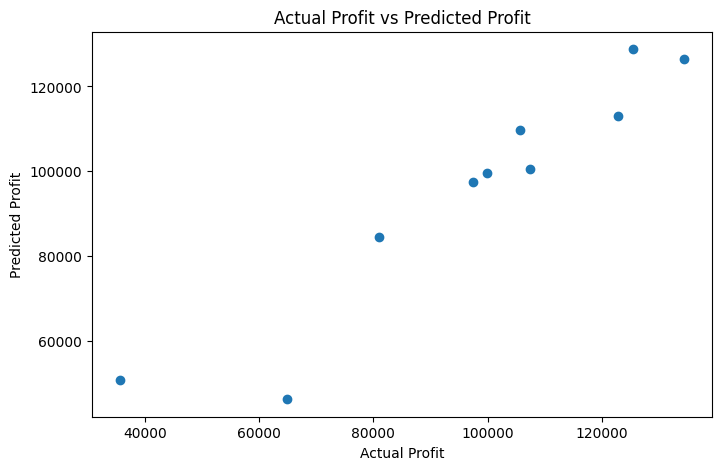

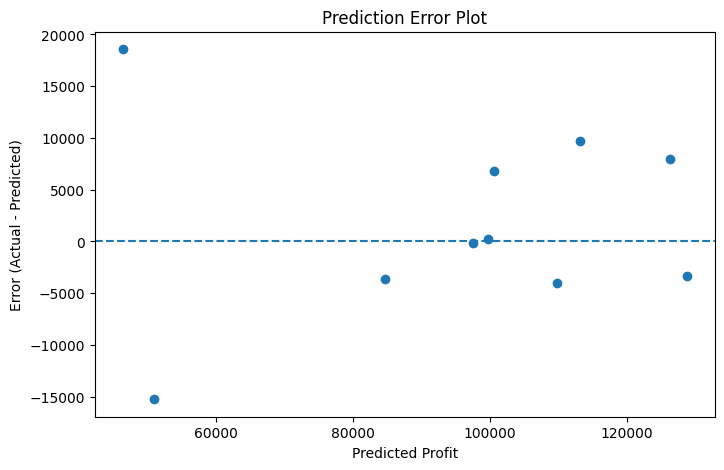


===== NEW STARTUP PREDICTION =====
Predicted Profit: 153720.28489481434


In [2]:

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------
# 2. Load dataset
# ------------------------------------------
df = pd.read_csv("50_Startups.csv")

# ------------------------------------------
# 3. Basic dataset understanding
# ------------------------------------------
print("===== FIRST 5 ROWS =====")
print(df.head())

print("\n===== SHAPE OF DATASET =====")
print(df.shape)

print("\n===== COLUMN NAMES =====")
print(df.columns)

print("\n===== DATA TYPES =====")
print(df.dtypes)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())

# ------------------------------------------
# 4. Separate features (X) and target (y)
# ------------------------------------------
# Target column = Profit
# Features = R&D Spend, Administration, Marketing Spend, State

X = df.drop("Profit", axis=1)
y = df["Profit"]

print("\n===== FEATURES (X) SAMPLE =====")
print(X.head())

print("\n===== TARGET (y) SAMPLE =====")
print(y.head())

# ------------------------------------------
# 5. Identify categorical and numerical columns
# ------------------------------------------
categorical_cols = ["State"]
numerical_cols = ["R&D Spend", "Administration", "Marketing Spend"]

# ------------------------------------------
# 6. Preprocessing
# Convert categorical column State into numbers using OneHotEncoder
# drop='first' avoids dummy variable trap
# ------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# ------------------------------------------
# 7. Build full pipeline
# Preprocessing + Model together
# ------------------------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# ------------------------------------------
# 8. Split dataset into train and test
# 80% train, 20% test
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n===== TRAIN TEST SHAPES =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ------------------------------------------
# 9. Train model
# ------------------------------------------
model.fit(X_train, y_train)

print("\nModel training completed successfully!")

# ------------------------------------------
# 10. Predict on test data
# ------------------------------------------
y_pred = model.predict(X_test)

# ------------------------------------------
# 11. Compare Actual vs Predicted
# ------------------------------------------
results = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred
})

print("\n===== ACTUAL VS PREDICTED =====")
print(results)

# ------------------------------------------
# 12. Model evaluation
# ------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL EVALUATION =====")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2 Score : {r2:.4f}")

# ------------------------------------------
# 13. Intercept and coefficients
# ------------------------------------------
regressor = model.named_steps["regressor"]
encoder = model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = encoder.get_feature_names_out()

coeff_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": regressor.coef_
})

print("\n===== MODEL INTERCEPT =====")
print(regressor.intercept_)

print("\n===== FEATURE COEFFICIENTS =====")
print(coeff_df)

# ------------------------------------------
# 14. Visualization: Actual vs Predicted
# ------------------------------------------
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual Profit vs Predicted Profit")
plt.show()

# ------------------------------------------
# 15. Visualization: Prediction Error
# ------------------------------------------
errors = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, errors)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Profit")
plt.ylabel("Error (Actual - Predicted)")
plt.title("Prediction Error Plot")
plt.show()

# ------------------------------------------
# 16. Predict for new startup data
# Example:
# State = Florida
# R&D Spend = 120000
# Administration = 100000
# Marketing Spend = 300000
# ------------------------------------------
new_data = pd.DataFrame({
    "R&D Spend": [120000],
    "Administration": [100000],
    "Marketing Spend": [300000],
    "State": ["Florida"]
})

new_prediction = model.predict(new_data)

print("\n===== NEW STARTUP PREDICTION =====")
print("Predicted Profit:", new_prediction[0])